In [14]:
import pandas as pd

In [15]:
# Create prescription frequency table
prescriptions = pd.read_csv('mimic-iv-3.1/hosp/prescriptions.csv',
                        usecols=['subject_id', 'drug', 'ndc', 'gsn'])

drug_counts = prescriptions['ndc'].value_counts().reset_index()
drug_counts.columns = ['ndc', 'count']
merged = pd.merge(drug_counts, prescriptions[['ndc', 'drug', 'gsn']], on='ndc', how='right').drop_duplicates('ndc')
print(merged.head(20))

merged.to_csv("derived/prescription_counts.csv", index=False)

/tmp/ipykernel_536669/1313998758.py:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  prescriptions = pd.read_csv('mimic-iv-3.1/hosp/prescriptions.csv',


             ndc      count                               drug     gsn
0   5.107901e+10    23275.0                         Furosemide  008209
1   4.879801e+08    37029.0            Ipratropium Bromide Neb  021700
2   5.107901e+10    35597.0                         Furosemide  008208
3   2.450041e+08    76460.0                 Potassium Chloride  001275
4   0.000000e+00  2518625.0        Sodium Chloride 0.9%  Flush     NaN
5   6.022761e+06     1577.0                        Raltegravir  063231
6   6.373905e+10     7368.0                     Spironolactone  006817
7   9.041989e+08   103619.0                      Acetaminophen  004490
8   1.951509e+10    13963.0     Influenza Vaccine Quadrivalent  072514
9   1.730682e+08    21994.0                  Albuterol Inhaler  028090
10  6.195807e+10     3405.0  Emtricitabine-Tenofovir (Truvada)  057883
12  6.332303e+10   316791.0                            Heparin  006549
13  1.350195e+08     4908.0                     Nicotine Patch  016426
15  6.

In [16]:
# Create procudure frequency table
procedures = pd.read_csv('mimic-iv-3.1/hosp/procedures_icd.csv',
                        usecols=['subject_id', 'seq_num', 'chartdate', 'icd_code'])

code_to_name = pd.read_csv('mimic-iv-3.1/hosp/d_icd_procedures.csv')

procedure_counts = procedures['icd_code'].value_counts().reset_index()
procedure_counts.columns = ['icd_code', 'count']
merged = pd.merge(procedure_counts, procedures[['icd_code']], on='icd_code', how='right').drop_duplicates('icd_code')
code_to_label = code_to_name.set_index('icd_code')['long_title'].to_dict()
merged["long_title"] = merged['icd_code'].map(code_to_label)
print(merged.head(20))

merged.to_csv("derived/procedure_counts.csv", index=False)

   icd_code  count                                         long_title
0      5491   6549                    Percutaneous abdominal drainage
3      8938  10519        Other nonoperative respiratory measurements
4   0QS734Z    103  Reposition Left Upper Femur with Internal Fixa...
6      5551    315                                 Nephroureterectomy
7      3734   1482  Excision or destruction of other lesion or tis...
8      3728    356                      Intracardiac echocardiography
9      3727   1221                                    Cardiac mapping
10     3893  14644   Venous catheterization, not elsewhere classified
11     4524    619                             Flexible sigmoidoscopy
12     7569   4947       Repair of other current obstetric laceration
21     5011   1031     Closed (percutaneous) [needle] biopsy of liver
22     4562    784         Other partial resection of small intestine
23     5459   1992                Other lysis of peritoneal adhesions
24  0FB23ZX    125  

In [17]:
# Calculate some basic descriptive statistics from the dataset
admissions = pd.read_csv('mimic-iv-3.1/hosp/admissions.csv',
                            usecols=['subject_id', 'hadm_id', 'admittime', 'dischtime',
                                    'deathtime', 'admission_type', 'admission_location',
                                    'insurance', 'race', 'hospital_expire_flag'])

print("Number of stays", admissions.shape[0])
print("Unique patients", admissions['subject_id'].unique().shape[0])

admissions['admittime'] = pd.to_datetime(admissions['admittime'])
admissions['dischtime'] = pd.to_datetime(admissions['dischtime'])
admissions['los_hours'] = (admissions['dischtime'] - admissions['admittime'])
print("Median stay:", admissions['los_hours'].median())
print("Mean stay:", admissions['los_hours'].mean())

num_dead = admissions[admissions['hospital_expire_flag']==1]['hospital_expire_flag'].count()
print("Dead in hospital", num_dead, num_dead / admissions.shape[0])

Number of stays 546028
Unique patients 223452
Median stay: 2 days 19:38:00
Mean stay: 4 days 18:16:54.480283062
Dead in hospital 11801 0.02161244478305142


In [18]:
lab_items = pd.read_csv('derived/lab_counts.csv')
lab_items = lab_items.sort_values('count', ascending=False)
lab_items = lab_items[lab_items['count'] > 546028/200]
print("Lab items used on more than 1 percent of patients:", lab_items.shape[0])
lab_items.head(10)

Lab items used on more than 1 percent of patients: 230


,index,itemid,label,count
124,124,50971,Potassium,2646744
133,133,50983,Sodium,2625553
73,73,50902,Chloride,2601011
83,83,50912,Creatinine,2585829
301,301,51221,Hematocrit,2574002
150,150,51006,Urea Nitrogen,2566692
58,58,50882,Bicarbonate,2546447
52,52,50868,Anion Gap,2541252
96,96,50931,Glucose,2517354
331,331,51265,Platelet Count,2457777


In [19]:
procedure_counts = pd.read_csv('derived/procedure_counts.csv')
procedure_counts = procedure_counts.sort_values('count', ascending=False)
procedure_counts = procedure_counts[procedure_counts['count'] > 546028/200]
print("Procedures performed on more than 1 percent of patients:", procedure_counts.shape[0])
procedure_counts.head(10)

Procedures performed on more than 1 percent of patients: 55


,icd_code,count,long_title
7,3893,14644,"Venous catheterization, not elsewhere classified"
42,02HV33Z,14353,Insertion of Infusion Device into Superior Ven...
1,8938,10519,Other nonoperative respiratory measurements
28,3897,10347,Central venous catheter placement with guidance
20,8856,9549,Coronary arteriography using two catheters
71,3E0G76Z,8700,Introduction of Nutritional Substance into Upp...
124,966,8165,Enteral infusion of concentrated nutritional s...
227,3995,7808,Hemodialysis
76,0040,7581,Procedure on single vessel
120,9671,7382,Continuous invasive mechanical ventilation for...


In [20]:
prescription_counts = pd.read_csv('derived/prescription_counts.csv')
prescription_counts = prescription_counts.sort_values('count', ascending=False)
prescription_counts = prescription_counts[prescription_counts['count'] > 546028/200]
print("Prescriptions given to more than 1 percent of patients:", prescription_counts.shape[0])
prescription_counts.head(10)

Prescriptions given to more than 1 percent of patients: 954


,ndc,count,drug,gsn
4,0.000000e+00,2518625.0,Sodium Chloride 0.9% Flush,NaN
49,3.380049e+08,384236.0,Sodium Chloride 0.9%,1210.0
11,6.332303e+10,316791.0,Heparin,6549.0
52,3.380117e+08,292265.0,Lactated Ringers,1187.0
95,4.096729e+08,227783.0,Magnesium Sulfate,16546.0
225,2.751001e+06,223404.0,Insulin,27413.0
235,8.822203e+07,222789.0,Insulin,47780.0
68,9.042245e+08,219619.0,Docusate Sodium,3009.0
59,4.060553e+08,198167.0,OxycoDONE (Immediate Release),4225.0
31,9.045166e+08,172054.0,Senna,19964.0


Labs matched:        65 / 65
Drugs matched:      121 / 121
Procedures matched:  17 / 17

OLS: |LASSO coefficient| ~ log10(frequency)
  lab           slope=+0.0303  R²=0.2298  p=0.0001  n=65
  drug          slope=+0.0589  R²=0.1842  p=0.0000  n=121
  procedure     slope=+0.0249  R²=0.0082  p=0.7290  n=17


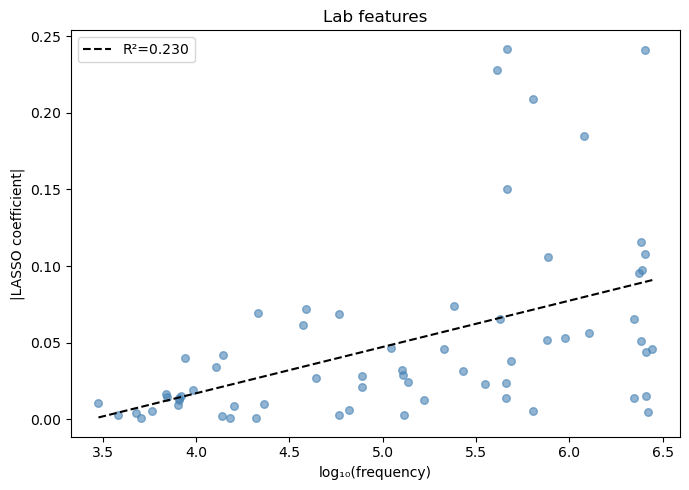

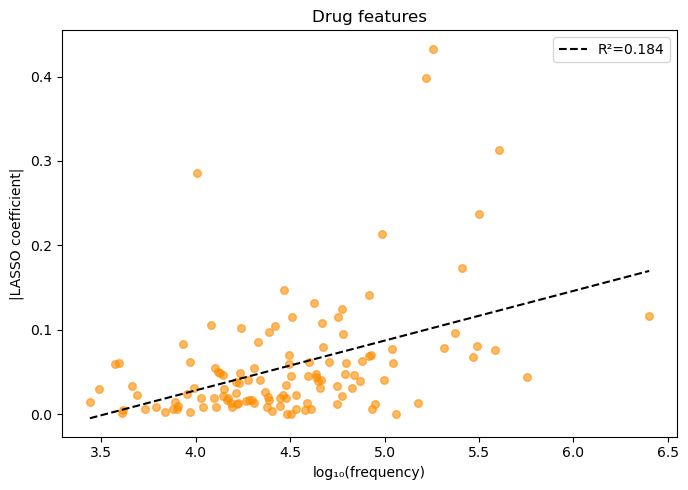

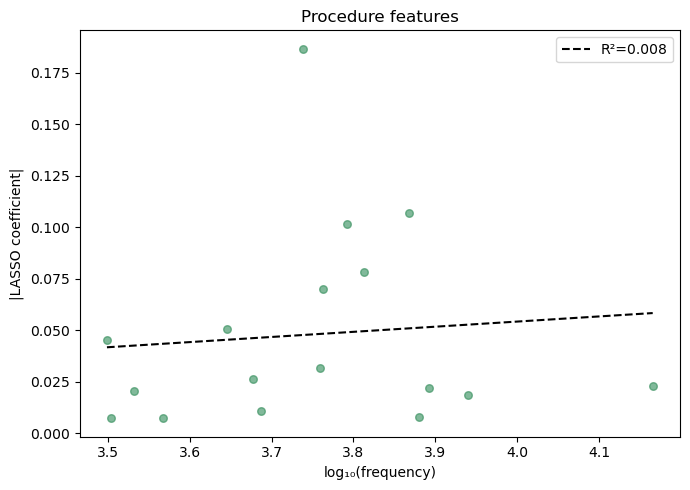

In [21]:
# Regression to find correlation between lab/procedure/prescription frequency and predictive power

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Load LASSO coefficients 
coefs = pd.read_csv('results/coef_series.csv', header=0, names=['feature', 'coefficient'])
coefs = coefs[coefs['coefficient'] != 0]

# Labs 
lab_coefs = coefs[coefs['feature'].str.startswith('lab_')].copy()
lab_coefs['key'] = lab_coefs['feature'].str[4:]          # strip 'lab_'

lab_counts = pd.read_csv('derived/lab_counts.csv')
lab_counts['key'] = lab_counts['label'].str.lower().str.replace(' ', '_')
lab_counts_agg = lab_counts.groupby('key')['count'].sum().reset_index()

lab_merged = lab_coefs.merge(lab_counts_agg, on='key', how='inner')
print(f"Labs matched:       {len(lab_merged):3d} / {len(lab_coefs)}")

# Drugs 
drug_coefs = coefs[coefs['feature'].str.startswith('drug_')].copy()
drug_coefs['key'] = drug_coefs['feature'].str[5:]        # strip 'drug_'

drug_counts = pd.read_csv('derived/prescription_counts.csv')
drug_counts['key'] = drug_counts['drug'].str.lower().str.replace(' ', '_')
drug_counts_agg = drug_counts.groupby('key')['count'].sum().reset_index()

drug_merged = drug_coefs.merge(drug_counts_agg, on='key', how='inner')
print(f"Drugs matched:      {len(drug_merged):3d} / {len(drug_coefs)}")

# Procedures 
proc_coefs = coefs[coefs['feature'].str.startswith('procedure_')].copy()
proc_coefs['key'] = proc_coefs['feature'].str[10:]       # strip 'procedure_'

proc_counts = pd.read_csv('derived/procedure_counts.csv')
proc_counts['key'] = proc_counts['icd_code'].astype(str)

proc_merged = proc_coefs.merge(proc_counts[['key', 'count']], on='key', how='inner')
print(f"Procedures matched: {len(proc_merged):3d} / {len(proc_coefs)}")

# Regression 
def run_ols(df, label=''):
    sl, ic, r, p, se = stats.linregress(df['log_count'], df['abs_coef'])
    print(f"  {label:12s}  slope={sl:+.4f}  R²={r**2:.4f}  p={p:.4f}  n={len(df)}")
    return sl, ic, r**2, p

for df in [lab_merged, drug_merged, proc_merged]:
    df['log_count'] = np.log10(df['count'])
    df['abs_coef'] = df['coefficient'].abs()

print("\nOLS: |LASSO coefficient| ~ log10(frequency)")
sl_lab, ic_lab, r2_lab, _ = run_ols(lab_merged,  'lab')
sl_drg, ic_drg, r2_drg, _ = run_ols(drug_merged, 'drug')
sl_prc, ic_prc, r2_prc, _ = run_ols(proc_merged, 'procedure')

# Plots 
plot_configs = [
    (lab_merged,  'Lab features',       'steelblue',  sl_lab, ic_lab, r2_lab),
    (drug_merged, 'Drug features',      'darkorange', sl_drg, ic_drg, r2_drg),
    (proc_merged, 'Procedure features', 'seagreen',   sl_prc, ic_prc, r2_prc),
]

for df, title, color, sl, ic, r2 in plot_configs:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(df['log_count'], df['abs_coef'], alpha=0.6, s=30, color=color)
    x = np.linspace(df['log_count'].min(), df['log_count'].max(), 100)
    ax.plot(x, sl * x + ic, 'k--', lw=1.5, label=f'R²={r2:.3f}')
    ax.set_xlabel('log₁₀(frequency)')
    ax.set_ylabel('|LASSO coefficient|')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


In [22]:
import joblib
lasso_model = joblib.load('results/lasso_model.joblib')

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
coefs = pd.read_csv('results/coef_series.csv')
coefs.head()

,Unnamed: 0,0
0,drug_warfarin,-0.432824
1,drug_heparin,-0.312938
2,drug_docusate_sodium,-0.237507
3,admission_type_SURGICAL SAME DAY ADMISSION,-0.235727
4,vital_min_spo2,-0.235609


In [24]:
# Make labels more readable to generate graphs
coefs['name'] = coefs['Unnamed: 0']
coefs['name'] = coefs['name'].astype(str).str.replace(r'^drug_(.*)$', r'\1 (drug)', regex=True)
coefs['name'] = coefs['name'].astype(str).str.replace(r'^vital_(.*)$', r'\1 (vital)', regex=True)
coefs['name'] = coefs['name'].astype(str).str.replace(r'^lab_(.*)$', r'\1 (lab)', regex=True)
coefs['name'] = coefs['name'].astype(str).str.replace(r'^admission_type_(.*)$', r'\1 (admission type)', regex=True)
coefs['name'] = coefs['name'].astype(str).str.replace(r'^admission_location_(.*)$', r'\1 (admission location)', regex=True)
coefs['name'] = coefs['name'].astype(str).str.replace('procedure_9671', 'mechanical ventilation <96h', regex=True)
coefs['name'] = coefs['name'].astype(str).str.replace('procedure_0BH17EZ', 'Endotrachial Airway Insertion', regex=True)
coefs['name'] = coefs['name'].astype(str).str.replace('procedure_5A1221Z', 'Performance of Cardiac Output', regex=True)


coefs.head(10)

,Unnamed: 0,0,name
0,drug_warfarin,-0.432824,warfarin (drug)
1,drug_heparin,-0.312938,heparin (drug)
2,drug_docusate_sodium,-0.237507,docusate_sodium (drug)
3,admission_type_SURGICAL SAME DAY ADMISSION,-0.235727,SURGICAL SAME DAY ADMISSION (admission type)
4,vital_min_spo2,-0.235609,min_spo2 (vital)
5,vital_min_heart_rate,-0.234618,min_heart_rate (vital)
6,lab_albumin,-0.227768,albumin (lab)
7,procedure_5A1221Z,-0.186599,Performance of Cardiac Output
8,lab_eosinophils,-0.150224,eosinophils (lab)
9,drug_phosphorus,-0.146765,phosphorus (drug)


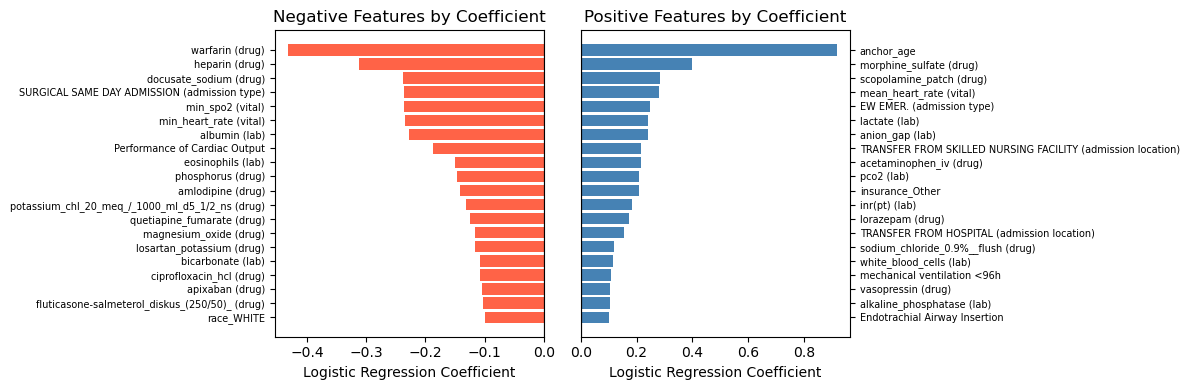

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Top feature coefficients
coef_series = pd.Series(coefs['0'].values, index=coefs['name'].values)
top__neg_coef = coef_series[coef_series != 0].sort_values(ascending=True).head(20)
signed_top = coef_series[top__neg_coef.index]
axes[0].barh(signed_top.index[::-1], signed_top.values[::-1], color='tomato')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Logistic Regression Coefficient')
axes[0].set_title('Negative Features by Coefficient')
axes[0].tick_params(axis='y', labelsize=7)

coef_series = pd.Series(coefs['0'].values, index=coefs['name'].values)
top_pos_coef = coef_series[coef_series != 0].sort_values(ascending=False).head(20)
signed_top = coef_series[top_pos_coef.index]
axes[1].barh(signed_top.index[::-1], signed_top.values[::-1], color='steelblue')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Logistic Regression Coefficient')
axes[1].set_title('Positive Features by Coefficient')
axes[1].tick_params(axis='y', labelsize=7)
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.tick_right()

plt.tight_layout()
#plt.savefig('results/logistic_regression_results.png', dpi=120, bbox_inches='tight')
plt.show()

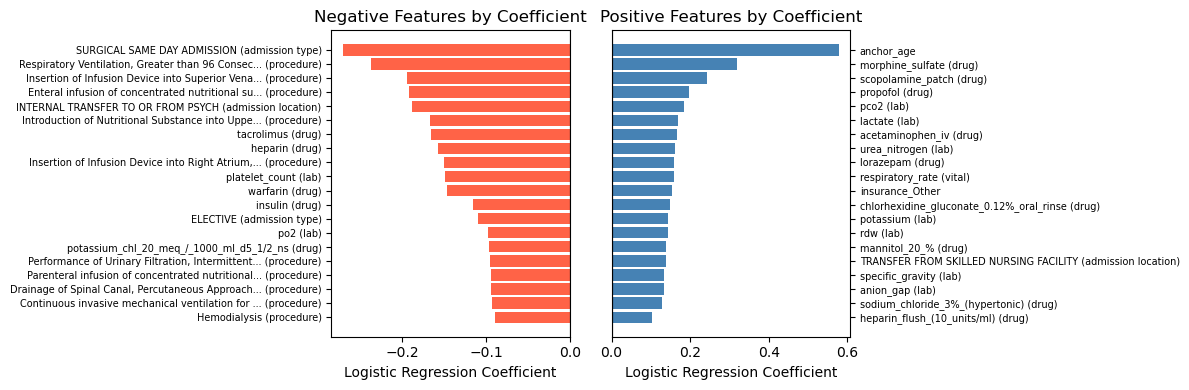

In [28]:
# Decompensation coefficient plots
import pandas as pd
import matplotlib.pyplot as plt

# Load procedure name lookup
d_icd = pd.read_csv('mimic-iv-3.1/hosp/d_icd_procedures.csv')
proc_lookup = dict(zip(d_icd['icd_code'], d_icd['long_title']))

def readable_name(feat):
    if not isinstance(feat, str):
        return str(feat)
    if feat.startswith('drug_'):
        return feat.replace('drug_', '') + ' (drug)'
    if feat.startswith('vital_') and feat.endswith('_missing'):
        return feat.replace('vital_', '').replace('_missing', '') + ' (vital missing)'
    if feat.startswith('vital_'):
        return feat.replace('vital_', '') + ' (vital)'
    if feat.startswith('lab_') and feat.endswith('_missing'):
        return feat.replace('lab_', '').replace('_missing', '') + ' (lab missing)'
    if feat.startswith('lab_'):
        return feat.replace('lab_', '') + ' (lab)'
    if feat.startswith('procedure_'):
        code = feat.replace('procedure_', '')
        name = proc_lookup.get(code, code)
        if len(name) > 50:
            name = name[:47] + '...'
        return name + ' (procedure)'
    if feat.startswith('admission_type_'):
        return feat.replace('admission_type_', '') + ' (admission type)'
    if feat.startswith('admission_location_'):
        return feat.replace('admission_location_', '') + ' (admission location)'
    return feat

for csv_path, title_suffix, save_path in [
    ('results/decompensation_coef_series.csv', 'Decompensation', 'results/decompensation_coef_plot.png'),
]:
    coefs = pd.read_csv(csv_path, header=None, names=['feature', 'coef'])
    coefs = coefs.dropna(subset=['feature', 'coef'])
    coefs['name'] = coefs['feature'].apply(readable_name)
    coef_series = pd.Series(coefs['coef'].values, index=coefs['name'].values)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    top_neg = coef_series[coef_series != 0].sort_values(ascending=True).head(20)
    axes[0].barh(top_neg.index[::-1], top_neg.values[::-1], color='tomato')
    axes[0].axvline(0, color='black', linewidth=0.8)
    axes[0].set_xlabel('Logistic Regression Coefficient')
    axes[0].set_title(f'Negative Features by Coefficient')
    axes[0].tick_params(axis='y', labelsize=7)

    top_pos = coef_series[coef_series != 0].sort_values(ascending=False).head(20)
    axes[1].barh(top_pos.index[::-1], top_pos.values[::-1], color='steelblue')
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].set_xlabel('Logistic Regression Coefficient')
    axes[1].set_title(f'Positive Features by Coefficient')
    axes[1].tick_params(axis='y', labelsize=7)
    axes[1].yaxis.set_label_position("right")
    axes[1].yaxis.tick_right()

    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()